# This notebook demonstrates the matter effect in oscillograms.

In [2]:
# constants
import numpy as np
import matplotlib.pyplot as plt
s23 = 0.47 # sin^2(theta23)
s13 = 0.022 # sin^2(theta13)
dm31 = 2.5e-3 # eV^2
r_e = 6371 # earth radius in km

# 1. $P_{\mu e}$

 Let's start from $\nu_e$ appearance from $\nu_\mu$ in a vacuum and try to understand the shape.
- The bright stripes corresponds to the oscillation maximums. That is, when $\Delta_m^2 L/E = \pi/2 + n\pi (n = 0,1,2,...)$. From left to right, the first stripe corresponds to $n=0$, second $n=1$, etc.
- When L is fixed, the width of stripes becomes wider with higher energy. That's because it goes like $\sin(1/x)$
- When E is fixed, the width of stripes stays the same because it goes like $\sin(x)$

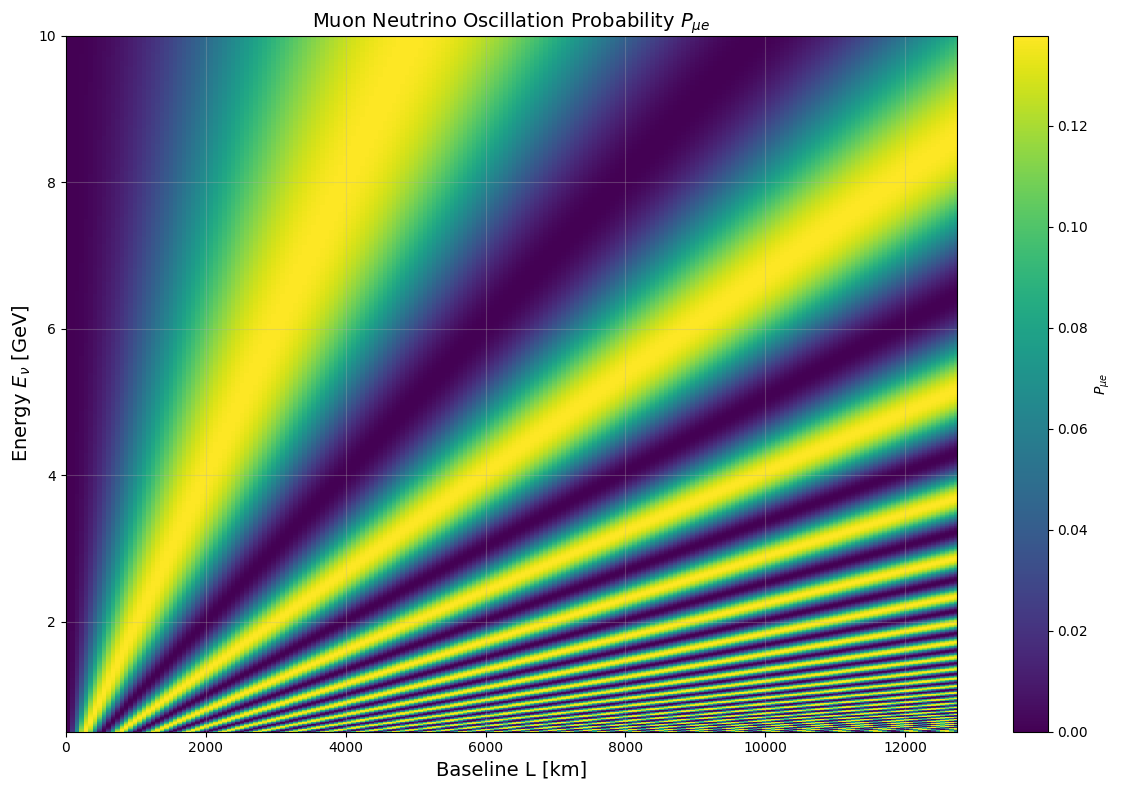

In [19]:
def osc_prob_toy(L, E):
    s13v = np.sqrt(s13)
    c13v = np.sqrt(1.0 - s13)
    dm = 2.5e-3
    s23 = 0.47
    sin2theta13 = 2.0 * s13v * c13v
    return s23 * sin2theta13 * np.sin(1.27 * dm * L / E)**2

L_array = np.linspace(0, 12742, 200)
E_array = np.linspace(0.5, 10, 1000)
prob_grid = np.zeros((len(E_array), len(L_array)))
for i, E in enumerate(E_array):
    for j, L in enumerate(L_array):
        prob_grid[i, j] = osc_prob_toy(L, E)
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[L_array[0], L_array[-1],
                        E_array[0], E_array[-1]],
                cmap='viridis', interpolation='nearest')
plt.xlabel('Baseline L [km]', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu e}$', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu e}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Now let's plot the oscillation probability with matter effect included. \
Notice the matter alters two parameters: **mass splitting** and **mixing**. \
First let's make sure that we recover vacuum oscillation when both are turned off.

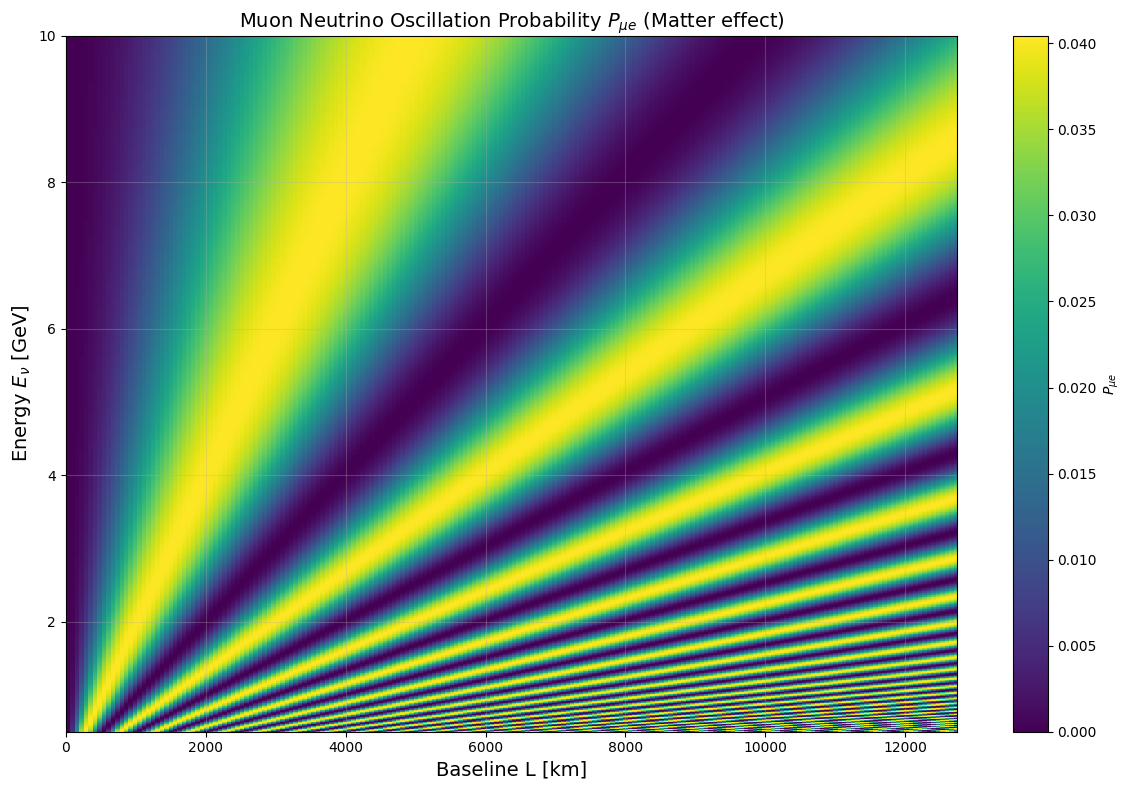

In [8]:
def osc_mat_toy(L, E, mass = True, mixing = True):
    s13v = np.sqrt(s13)
    c13v = np.sqrt(1.0 - s13)
    dm = 2.5e-3
    s23 = 0.47
    A = 7.56e-5 * 0.5 * 2.8 * E
    sin2theta13 = 2.0 * s13v * c13v
    cos2theta13 = 1.0 - 2.0 * s13
    # effective atmospheric splitting in matter
    dm31_m = np.sqrt((dm31 * cos2theta13 - A)**2 + (dm31 * sin2theta13)**2)

    # # matter-modified theta13
    sin2_2theta13_m = (dm31 * sin2theta13)**2 / (
        (dm31 * cos2theta13 - A)**2 + (dm31 * sin2theta13)**2
    )
    if mixing and not mass:
        return s23 * sin2_2theta13_m * np.sin(1.27 * dm31 * L / E)**2
    elif not mixing and mass:
        return s23 * sin2theta13**2 * np.sin(1.27 * dm31_m * L / E)**2
    elif mixing and mass:
        return s23 * sin2_2theta13_m * np.sin(1.27 * dm31_m * L / E)**2
    else:
        return s23 * sin2theta13**2 * np.sin(1.27 * dm31 * L / E)**2
L_array = np.linspace(0, 12742, 200)
E_array = np.linspace(0.5, 10, 1000)
prob_grid = np.zeros((len(E_array), len(L_array)))
for i, E in enumerate(E_array):
    for j, L in enumerate(L_array):
        prob_grid[i, j] = osc_mat_toy(L, E, mass=False, mixing=False)
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[L_array[0], L_array[-1],
                        E_array[0], E_array[-1]],
                cmap='viridis', interpolation='nearest')
plt.xlabel('Baseline L [km]', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu e}$ (Matter effect)', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu e}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Now turn on the effective atmospheric splitting in matter. \
**Spitting controls the shape of the stripes. Matter effect on mass splitting skews the stripes**
- Notice the slope of the bright stripe(constant probability) is not constant anymore. L/E increases with higher energy. The stripes shift to the right.
- This is because the mass splitting is now energy dependent through the potential term $A$.\
The first oscillation maximum now corresponds to \
$\frac{L}{E} = \frac{\pi}{2} \frac{1}{\sqrt{(\Delta m^2\cos(2\theta_{13})-A)^2+(\Delta m^2\sin(2\theta_{13}))^2}}$
- However, within the stripe(same L/E), oscillation probability remains constant. Because the amplitude of the oscillation is constant.

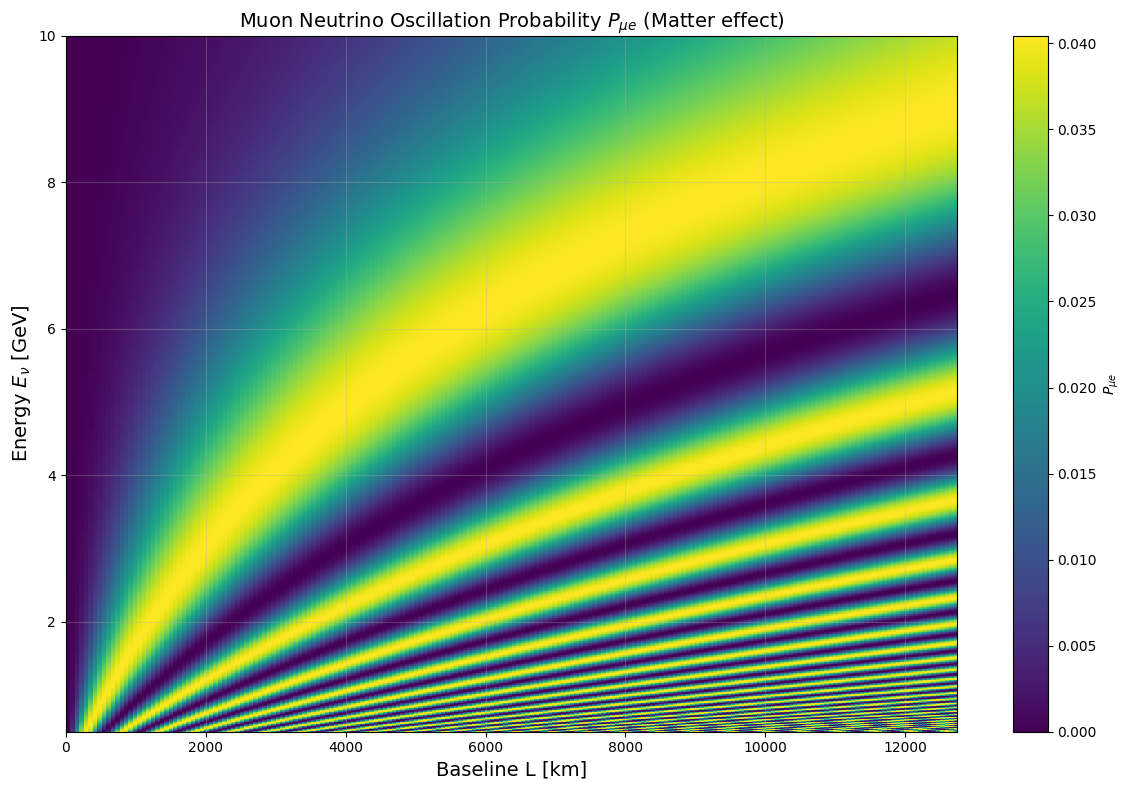

In [66]:
def osc_mat_toy(L, E, mass = True, mixing = True):
    s13v = np.sqrt(s13)
    c13v = np.sqrt(1.0 - s13)
    dm = 2.5e-3
    s23 = 0.47
    A = 2 * 7.56e-5 * 0.5 * 2.8 * E
    sin2theta13 = 2.0 * s13v * c13v
    cos2theta13 = 1.0 - 2.0 * s13
    # effective atmospheric splitting in matter
    dm31_m = np.sqrt((dm31 * cos2theta13 - A)**2 + (dm31 * sin2theta13)**2)

    # # matter-modified theta13
    sin2_2theta13_m = (dm31 * sin2theta13)**2 / (
        (dm31 * cos2theta13 - A)**2 + (dm31 * sin2theta13)**2
    )
    if mixing and not mass:
        return s23 * sin2_2theta13_m * np.sin(1.27 * dm31 * L / E)**2
    elif not mixing and mass:
        return s23 * sin2theta13**2 * np.sin(1.27 * dm31_m * L / E)**2
    elif mixing and mass:
        return s23 * sin2_2theta13_m * np.sin(1.27 * dm31_m * L / E)**2
    else:
        return s23 * sin2theta13**2 * np.sin(1.27 * dm31 * L / E)**2
L_array = np.linspace(0, 12742, 200)
E_array = np.linspace(0.5, 10, 1000)
prob_grid = np.zeros((len(E_array), len(L_array)))
for i, E in enumerate(E_array):
    for j, L in enumerate(L_array):
        prob_grid[i, j] = osc_mat_toy(L, E, mass=True, mixing=False)
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[L_array[0], L_array[-1],
                        E_array[0], E_array[-1]],
                cmap='viridis', interpolation='nearest')
plt.xlabel('Baseline L [km]', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu e}$ (Matter effect)', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu e}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Now turn off the matter-modified mass splitting and turn on the mixing matter effect.
**Matter effect on mixing doesn't change the shape of the stripes. It shifts values within the stripe.**
- Notice the slope of the stripes remains constant, but it shifts the probability to the highe energy tail.
- This is because the mixing is now energy dependent through $A$. It reaches maximum when 
$A = \Delta m_{31}^2 \cos 2\theta_{13}$ . That's when $\theta_{13}^m = 45^\circ$ and E~22GeV. (MSW resonance)

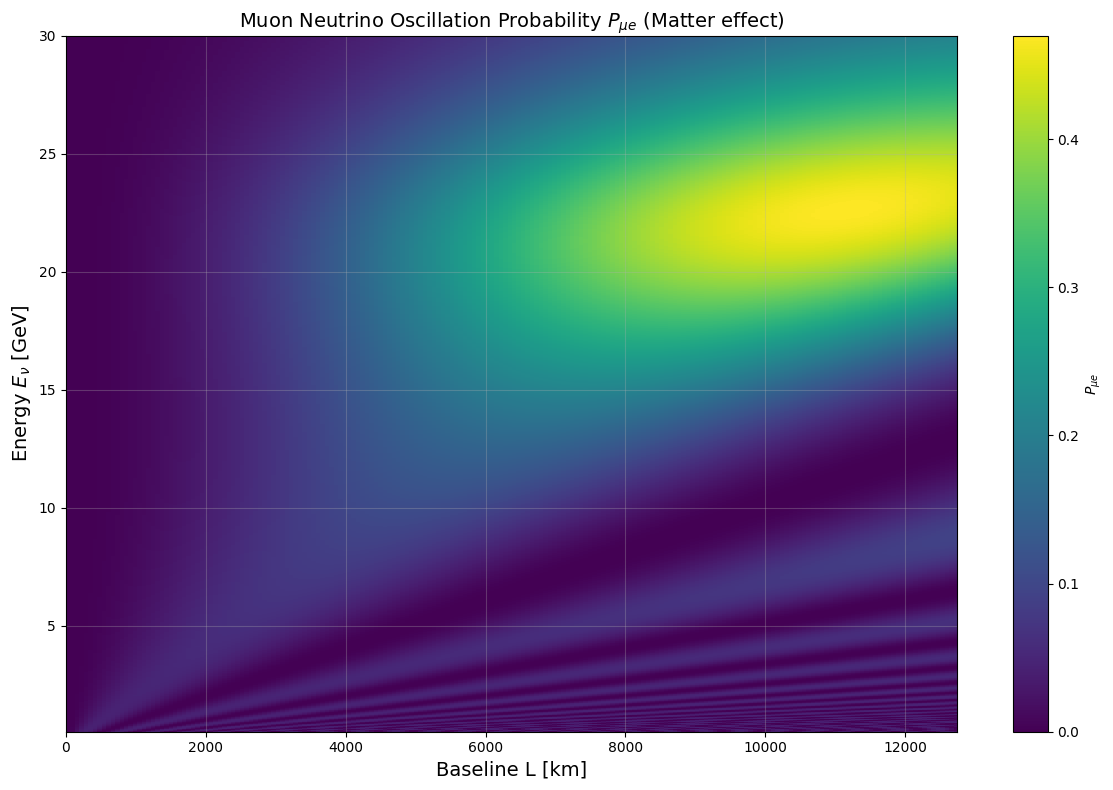

In [ ]:
L_array = np.linspace(0, 12742, 200)
E_array = np.linspace(0.5, 30, 1000)
prob_grid = np.zeros((len(E_array), len(L_array)))
for i, E in enumerate(E_array):
    for j, L in enumerate(L_array):
        prob_grid[i, j] = osc_mat_toy(L, E, mass=False, mixing=True)
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[L_array[0], L_array[-1],
                        E_array[0], E_array[-1]],
                cmap='viridis', interpolation='nearest')
plt.xlabel('Baseline L [km]', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu e}$ (Matter effect)', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu e}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Now let's turn on both effects. This gives us the combined matter effect.

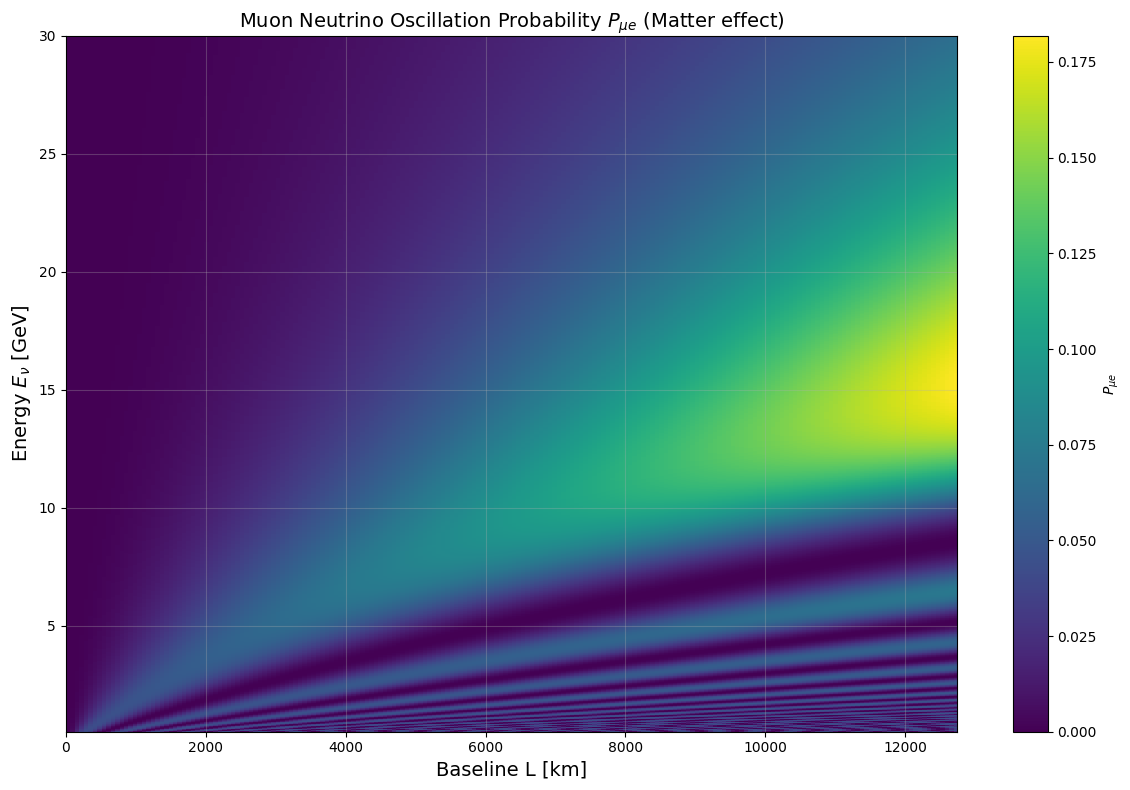

In [46]:
L_array = np.linspace(0, 12742, 200)
E_array = np.linspace(0.5, 30, 1000)
prob_grid = np.zeros((len(E_array), len(L_array)))
for i, E in enumerate(E_array):
    for j, L in enumerate(L_array):
        prob_grid[i, j] = osc_mat_toy(L, E, mass=True, mixing=True)
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[L_array[0], L_array[-1],
                        E_array[0], E_array[-1]],
                cmap='viridis', interpolation='nearest')
plt.xlabel('Baseline L [km]', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu e}$ (Matter effect)', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu e}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. $P_{\mu \tau}$

In [ ]:
2.5e-3*0.95/(7.56e-5*0.5*2.8)

22.4395313681028

In [65]:
r = 6371 # km
d = 20
s = 1.5
def prop_length(x):
    # x is cos(theta)
    sqrt = np.sqrt(4*x**2*(s-r)**2-4*(s**2-2*r*s-d**2-2*r*d))
    return 1/2 * (-2*x*(r-s)+sqrt)

def baseline(x):
    if x < 0:
        L = -2*r*x
    else:
        L = prop_length(x)
    return L

def p_mutau_vac(x, E, baseline_type='cos'):
    # 2 level approximation for numu to nutau appearance
    if baseline_type == 'cos':
        L = baseline(x)
    elif baseline_type == 'km':
        L = x
    else:
        raise ValueError("Invalid baseline type. Use 'cos' or 'km'.")
    
    # angles
    s13v = np.sqrt(s13)
    c13v = np.sqrt(1.0 - s13)
    sin2_2theta23 = 4.0 * s23 * (1.0 - s23)

    return c13v**4 * sin2_2theta23 * np.sin(1.27 * dm31 * L / E)**2

def p_mutau_matter(x, E, Ye = 0.5, rho = 2.8, baseline_type = 'cos'):
    if baseline_type == 'cos':
        L = baseline(x)
    elif baseline_type == 'km':
        L = x
    else:
        raise ValueError("Invalid baseline type. Use 'cos' or 'km'.")
    # angles
    s13v = np.sqrt(s13)
    c13v = np.sqrt(1.0 - s13)

    sin2_2theta23 = 4.0 * s23 * (1.0 - s23)
    sin2theta13 = 2.0 * s13v * c13v
    cos2theta13 = 1.0 - 2.0 * s13

    # matter potential in eV^2
    A = 2 * 7.56e-5 * Ye * rho * E

    # effective atmospheric splitting in matter
    dm31_m = np.sqrt((dm31 * cos2theta13 - A)**2 + (dm31 * sin2theta13)**2)

    # matter-modified theta13
    sin2_2theta13_m = (dm31 * sin2theta13)**2 / (
        (dm31 * cos2theta13 - A)**2 + (dm31 * sin2theta13)**2
    )

    cos2theta13_m = (dm31 * cos2theta13 - A) / dm31_m

    s13_m = 0.5 * (1.0 - cos2theta13_m)
    c13_m = 1.0 - s13_m

    # phases
    phase1 = 1.27 * (dm31 + A + dm31_m) * L / (2.0 * E)
    phase2 = 1.27 * (dm31 + A - dm31_m) * L / (2.0 * E)
    phase3 = 1.27 * dm31_m * L / E

    # terms
    term1 = c13_m * sin2_2theta23 * np.sin(phase1)**2
    term2 = s13_m * sin2_2theta23 * np.sin(phase2)**2
    term3 = sin2_2theta23 * sin2_2theta13_m/4 * np.sin(phase3)**2

    return term1 + term2 - term3

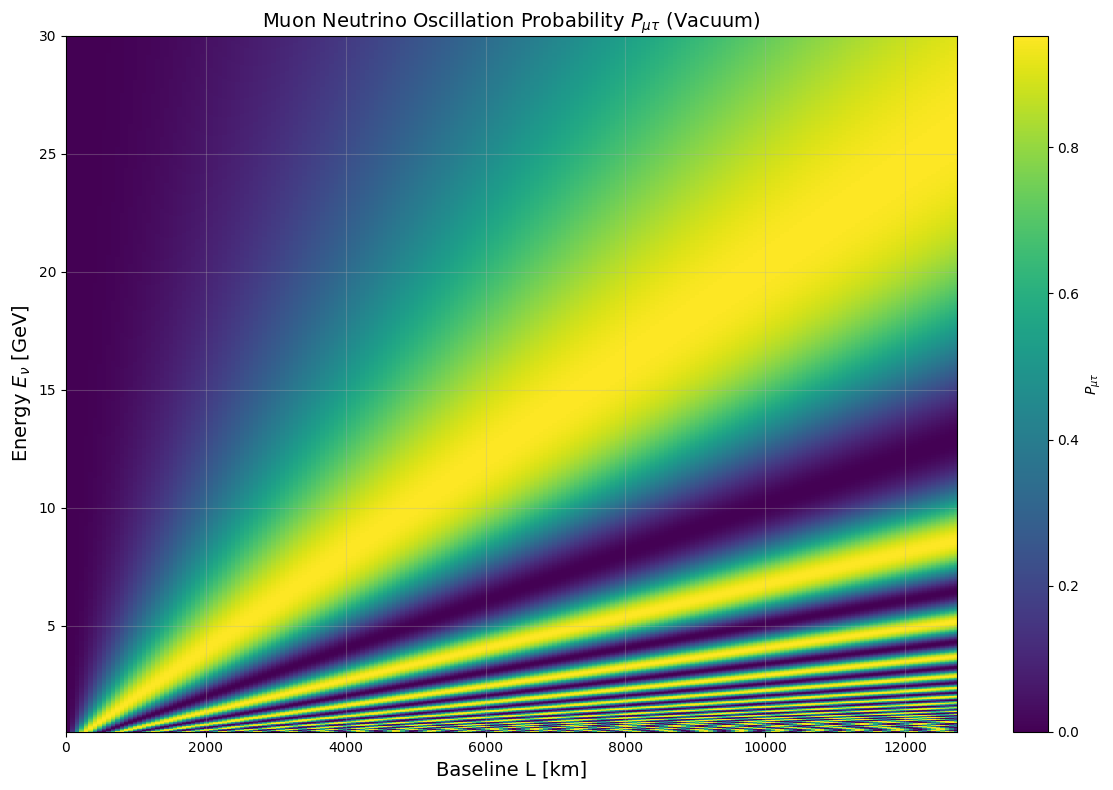

In [40]:
L_array = np.linspace(0, 12742, 200)
E_array = np.linspace(0.5, 30, 1000)
prob_grid = np.zeros((len(E_array), len(L_array)))
for i, E in enumerate(E_array):
    for j, L in enumerate(L_array):
        prob_grid[i, j] = p_mutau_vac(L, E, baseline_type = 'km')
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[L_array[0], L_array[-1],
                        E_array[0], E_array[-1]],
                cmap='viridis', interpolation='nearest')
plt.xlabel('Baseline L [km]', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu \tau}$ (Vacuum)', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu \tau}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

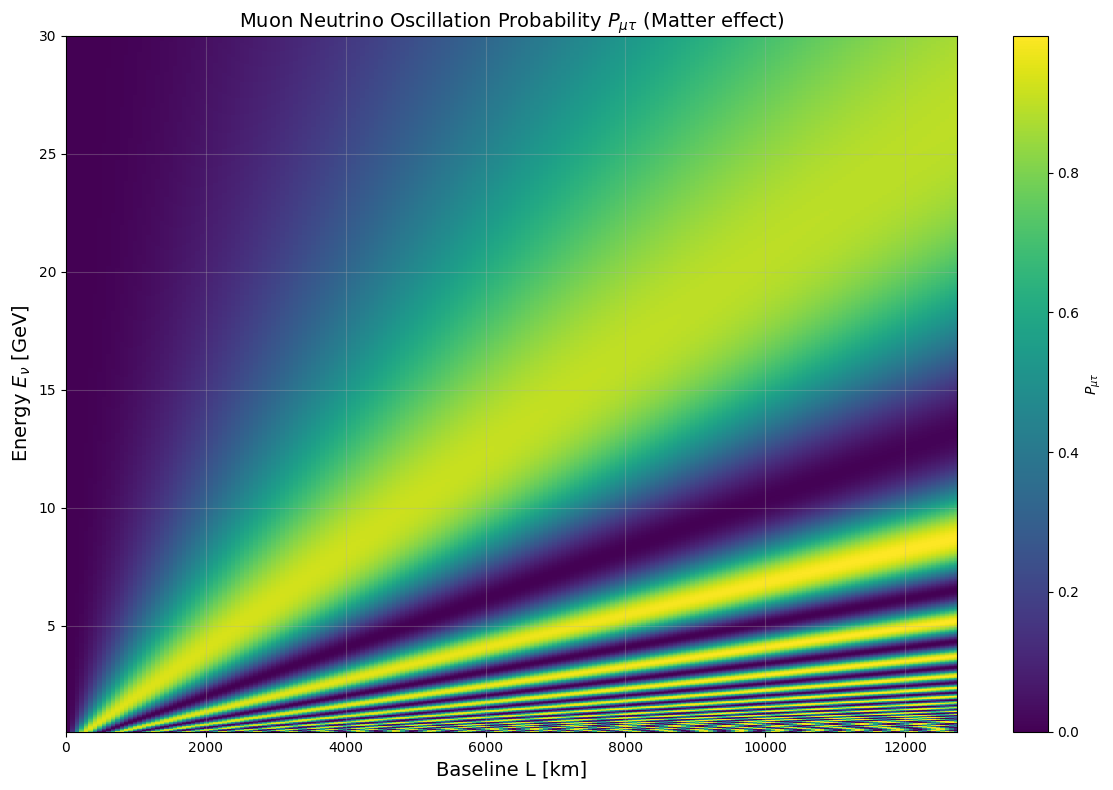

In [48]:
L_array = np.linspace(0, 12742, 200)
E_array = np.linspace(0.5, 30, 1000)
prob_grid = np.zeros((len(E_array), len(L_array)))
for i, E in enumerate(E_array):
    for j, L in enumerate(L_array):
        prob_grid[i, j] = p_mutau_matter(L, E, baseline_type = 'km')
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[L_array[0], L_array[-1],
                        E_array[0], E_array[-1]],
                cmap='viridis', interpolation='nearest')
plt.xlabel('Baseline L [km]', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu \tau}$ (Matter effect)', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu \tau}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

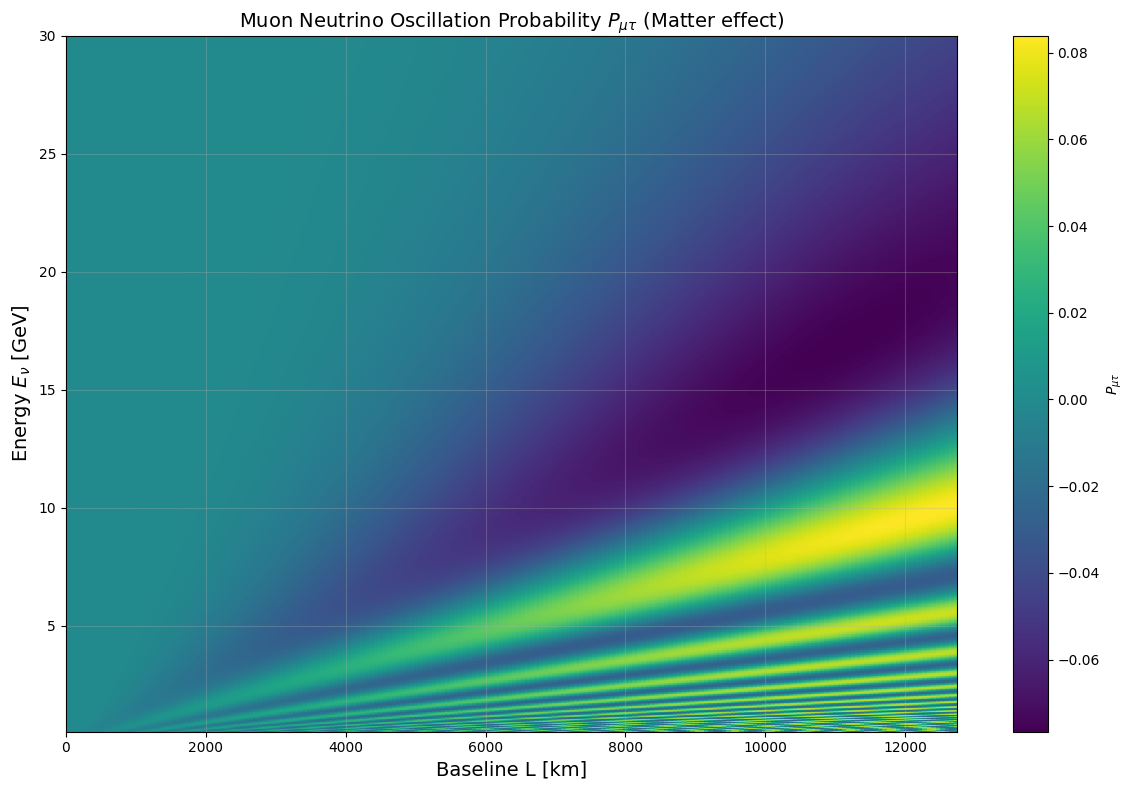

In [49]:
L_array = np.linspace(0, 12742, 200)
E_array = np.linspace(0.5, 30, 1000)
prob_grid = np.zeros((len(E_array), len(L_array)))
for i, E in enumerate(E_array):
    for j, L in enumerate(L_array):
        prob_grid[i, j] = p_mutau_matter(L, E, baseline_type = 'km')-p_mutau_vac(L, E, baseline_type = 'km')
plt.figure(figsize=(12, 8))
im = plt.imshow(prob_grid, aspect='auto', origin='lower',
                extent=[L_array[0], L_array[-1],
                        E_array[0], E_array[-1]],
                cmap='viridis', interpolation='nearest')
plt.xlabel('Baseline L [km]', fontsize=14)
plt.ylabel(r'Energy $E_\nu$ [GeV]', fontsize=14)
plt.title(r'Muon Neutrino Oscillation Probability $P_{\mu \tau}$ (Matter effect)', fontsize=14)
cbar = plt.colorbar(im, label=r'$P_{\mu \tau}$')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()